<a href="https://colab.research.google.com/github/Shravani046/Fibroid-Classification/blob/main/notebooks/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

GH_TOKEN = userdata.get("GH_TOKEN")
GH_USER = "Shravani046"
REPO = "Fibroid-Classification"

!git clone https://{GH_TOKEN}@github.com/{GH_USER}/{REPO}.git

%cd {REPO}
!git pull

Cloning into 'Fibroid-Classification'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 68 (delta 35), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 668.79 KiB | 2.70 MiB/s, done.
Resolving deltas: 100% (35/35), done.
/content/Fibroid-Classification
Already up to date.


In [2]:
!pip install -q kagglehub opencv-python-headless

import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from collections import defaultdict
import hashlib
import seaborn as sns

In [3]:
dataset_path = kagglehub.dataset_download("aureenblessingharazi/fibroid-ultrascans")
print("dataset root:",dataset_path)
for root, dirs, files in os.walk(dataset_path):
  depth = root.replace(dataset_path,'').count(os.sep)
  if depth <3:
    print(""*depth+os.path.basename(root)+"/",f"({len(files)} files" if files else "")

100%|██████████| 132M/132M [00:00<00:00, 148MB/s]

Extracting files...


dataset root: /root/.cache/kagglehub/datasets/aureenblessingharazi/fibroid-ultrascans/versions/1
1/ 
combinedataset/ 
non_fibroid/ (1525 files
fibroid/ (1525 files


In [4]:
dataset_path = kagglehub.dataset_download("aureenblessingharazi/fibroid-ultrascans")
dataset_path = os.path.join(dataset_path, "combinedataset")

In [5]:
records = []

classes = ["fibroid", "non_fibroid"]

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    print(folder)

    if not os.path.isdir(folder):
        print(f"{folder} not found")
        continue

    for fname in os.listdir(folder):
        records.append({
            "path": os.path.join(folder, fname),
            "class": cls,
            "filename": fname
        })

df = pd.DataFrame(records)

print("Total images indexed:", len(df))
df.head()

/root/.cache/kagglehub/datasets/aureenblessingharazi/fibroid-ultrascans/versions/1/combinedataset/fibroid
/root/.cache/kagglehub/datasets/aureenblessingharazi/fibroid-ultrascans/versions/1/combinedataset/non_fibroid
Total images indexed: 3050


,path,class,filename
0,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
1,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
2,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
3,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...
4,/root/.cache/kagglehub/datasets/aureenblessing...,fibroid,Uterine fibroid dataset_1-2-826-0-1-3680043-2-...


In [6]:
def check_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception as e:
        return False

df['is_valid'] = df['path'].apply(check_image)
corrupt = df[~df['is_valid']]

print(f"Corrupt/unreadable files: {len(corrupt)}")
if len(corrupt) > 0:
    print(corrupt[['path', 'split', 'class']])
    # Drop them now so downstream steps aren't affected
    df = df[df['is_valid']].reset_index(drop=True)

Corrupt/unreadable files: 0


In [7]:
import hashlib

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Generate hash for every image
df["hash"] = df["path"].apply(file_hash)

# Find duplicate images
dupes = df[df.duplicated("hash", keep=False)].sort_values("hash")

print(f"Total images: {len(df)}")
print(f"Unique images: {df['hash'].nunique()}")
print(f"Duplicate image files: {len(dupes)}")

# Show the most repeated images
print("\nTop repeated hashes:")
print(df["hash"].value_counts().head(10))

# Show duplicate statistics
duplicate_counts = df["hash"].value_counts().value_counts().sort_index()

print("\nDuplicate frequency:")
print(duplicate_counts)

# Preview duplicate images
if len(dupes) > 0:
    print("\nSample duplicate records:")
    print(dupes[["path", "class"]].head(20))

Total images: 3050
Unique images: 2545
Duplicate image files: 905

Top repeated hashes:
hash
64353f96dfc95d2ad3a50345879a93fc    6
d8849a5e21c136fb5b2820e076cc650c    6
54e09e0617a5e83bba92bedb3530d506    5
410124ffb786c198cb2f347d67f55f11    5
52bcb7241dc8f4939862b77b2d136a19    4
9b52d5dbe0b2539ecac2754be8d57021    4
34ac5966bb3d7ec1288f7c6ef2977126    4
016f29a57c2ebc2fb8340127127cfbfa    4
4ffb6f689c7bd4dda63cb6e058c30c94    4
43767d39e3d1803c264a263372006613    4
Name: count, dtype: int64

Duplicate frequency:
count
1    2145
2     315
3      71
4      10
5       2
6       2
Name: count, dtype: int64

Sample duplicate records:
                                                   path        class
184   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1119  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
2142  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2267  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
1498  /root/.ca

In [8]:
# Check if identical images have different labels
label_check = df.groupby("hash")["class"].nunique()

conflicting = label_check[label_check > 1]

print("Conflicting-label hashes:", len(conflicting))

if len(conflicting) > 0:
    bad_hashes = conflicting.index
    print(df[df["hash"].isin(bad_hashes)][["path", "class"]])

Conflicting-label hashes: 5
                                                   path        class
30    /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
269   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
298   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
482   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
828   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1076  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1203  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1358  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid
1733  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
1752  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
1771  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2013  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2807  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid
2844  

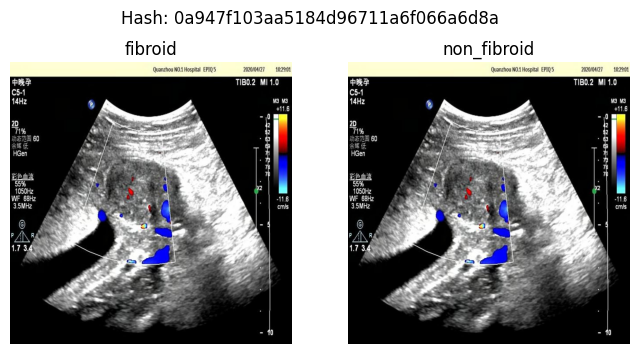

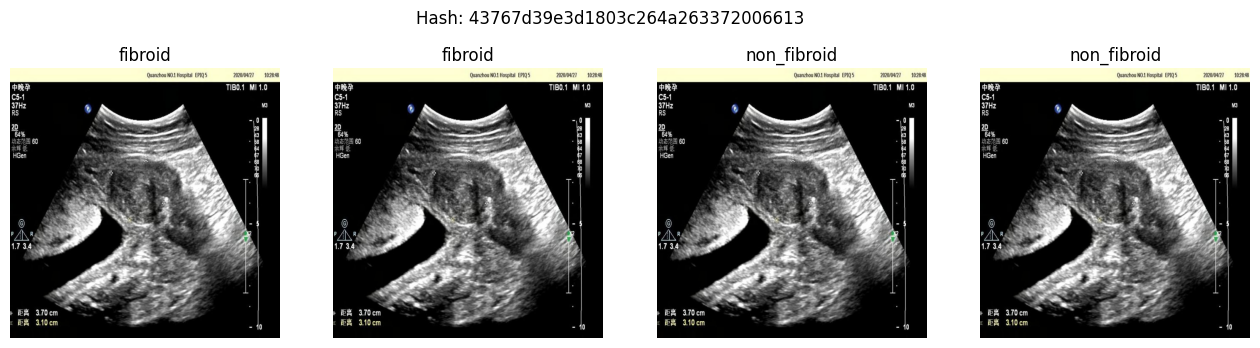

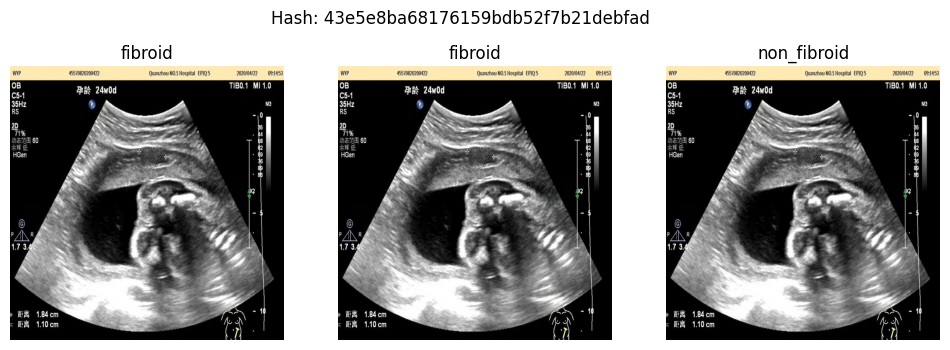

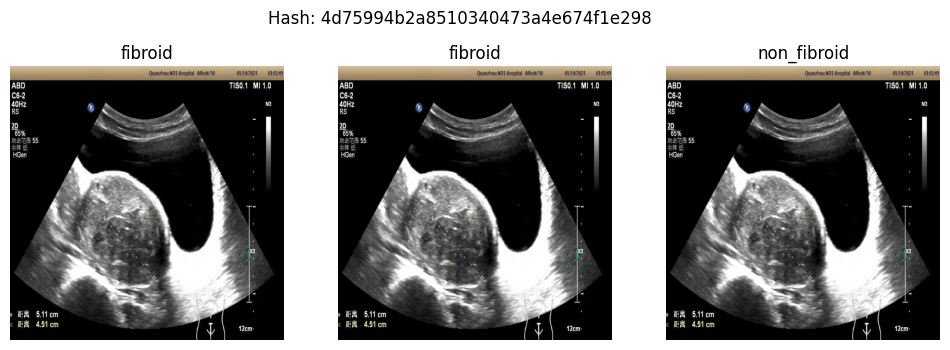

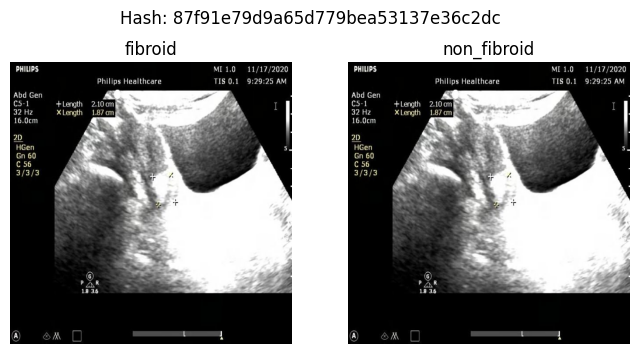

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

bad_hashes = conflicting.index

for h in bad_hashes:
    subset = df[df["hash"] == h]

    fig, axes = plt.subplots(1, len(subset), figsize=(4*len(subset),4))

    if len(subset) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.iterrows()):
        img = Image.open(row["path"])
        ax.imshow(img, cmap="gray")
        ax.set_title(row["class"])
        ax.axis("off")

    plt.suptitle(f"Hash: {h}")
    plt.show()

In [10]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['hash'] = df['path'].apply(file_hash)
print(f"Total: {len(df)} | Unique hashes: {df['hash'].nunique()}")
# Conflicting hashes: same image, different class labels
hash_class_counts = df.groupby('hash')['class'].nunique()
conflicting_hashes = hash_class_counts[hash_class_counts > 1].index.tolist()

print(f"Conflicting hashes (same image, different labels): {len(conflicting_hashes)}")
conflict_rows = df[df['hash'].isin(conflicting_hashes)].sort_values('hash')
print(conflict_rows[['path', 'class', 'hash']])

Total: 3050 | Unique hashes: 2545
Conflicting hashes (same image, different labels): 5
                                                   path        class  \
1076  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
2844  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
828   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1203  /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1752  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
2013  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
30    /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
482   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1771  /root/.cache/kagglehub/datasets/aureenblessing...  non_fibroid   
269   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
298   /root/.cache/kagglehub/datasets/aureenblessing...      fibroid   
1733  /root/.cache/kagglehub/datasets/aureenbless

In [11]:
# Pass 1: drop every copy of a conflicting-hash image entirely (label is unreliable, not salvageable by keeping one)
df_clean = df[~df['hash'].isin(conflicting_hashes)].copy()
print(f"After removing conflicts: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

# Pass 2: deduplicate remaining — keep first occurrence per hash
df_dedup = df_clean.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)
print(f"After deduplication: {len(df_dedup)} (dropped {len(df_clean) - len(df_dedup)} duplicate copies)")

print("\nFinal class balance:")
print(df_dedup['class'].value_counts())

After removing conflicts: 3036 (dropped 14)
After deduplication: 2540 (dropped 496 duplicate copies)

Final class balance:
class
non_fibroid    1456
fibroid        1084
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df_dedup,
    test_size=0.30,
    stratify=df_dedup['class'],
    random_state=42
)

# Second split: temp → 15% valid, 15% test (i.e., 50/50 of the 30%)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['class'],
    random_state=42
)

train_df = train_df.copy(); train_df['split'] = 'train'
valid_df = valid_df.copy(); valid_df['split'] = 'valid'
test_df = test_df.copy(); test_df['split'] = 'test'

split_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print(split_df.groupby(['split', 'class']).size().unstack())

class  fibroid  non_fibroid
split                      
test       163          218
train      759         1019
valid      162          219


In [13]:
train_hashes = set(train_df['hash'])
valid_hashes = set(valid_df['hash'])
test_hashes = set(test_df['hash'])

leak_train_valid = train_hashes & valid_hashes
leak_train_test = train_hashes & test_hashes
leak_valid_test = valid_hashes & test_hashes

print(f"Train∩Valid leakage: {len(leak_train_valid)}")
print(f"Train∩Test leakage:  {len(leak_train_test)}")
print(f"Valid∩Test leakage:  {len(leak_valid_test)}")

assert len(leak_train_valid) == 0, "LEAKAGE DETECTED: train/valid overlap"
assert len(leak_train_test) == 0, "LEAKAGE DETECTED: train/test overlap"
assert len(leak_valid_test) == 0, "LEAKAGE DETECTED: valid/test overlap"
print("\nZero leakage confirmed across all splits.")

Train∩Valid leakage: 0
Train∩Test leakage:  0
Valid∩Test leakage:  0

Zero leakage confirmed across all splits.


In [14]:
import shutil

output_root = 'data/splits'

for split in ['train', 'valid', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(output_root, split, cls), exist_ok=True)

for _, row in split_df.iterrows():
    dest = os.path.join(output_root, row['split'], row['class'], row['filename'])
    shutil.copy2(row['path'], dest)

print("Split folders created at:", output_root)

Split folders created at: data/splits


In [15]:
original_df = df.copy()

In [16]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [17]:
import os

os.makedirs("data", exist_ok=True)

split_df.to_csv("data/eda_inventory_final.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [18]:
!find . -name "eda_inventory_final.csv"

./data/eda_inventory_final.csv


In [19]:
!git pull --rebase origin main

error: cannot pull with rebase: You have unstaged changes.
error: please commit or stash them.


In [20]:
!find . -name "eda_inventory_final.csv"

./data/eda_inventory_final.csv


In [21]:
!git add data/eda_inventory_final.csv
!git add .gitignore
!git commit -m "data: add cleaned EDA inventory"
!git push

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@eddaf00a1ed4.(none)')
Everything up-to-date


In [22]:
!git rm notebooks/01_eda.ipynb

fatal: pathspec 'notebooks/01_eda.ipynb' did not match any files


In [23]:
!git add notebooks

!git commit -m "refactor: remove obsolete EDA notebook"

!git push

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@eddaf00a1ed4.(none)')
Everything up-to-date


In [24]:
from PIL import Image

sample = df.sample(min(300, len(df)), random_state=42)
dims = sample['path'].apply(lambda p: Image.open(p).size)
widths, heights = zip(*dims)

print(f"Width  — min: {min(widths)}, median: {np.median(widths):.0f}, max: {max(widths)}")
print(f"Height — min: {min(heights)}, median: {np.median(heights):.0f}, max: {max(heights)}")

TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25

Width  — min: 640, median: 640, max: 640
Height — min: 640, median: 640, max: 640


In [25]:
%%writefile src/preprocess.py
"""
Preprocessing module for fibroid classification pipeline.
Handles resizing, denoising, contrast enhancement, and quality checks.
"""
import cv2
import numpy as np

TARGET_SIZE = (224, 224)


def load_image(path, color_mode='rgb'):
    """Load image from disk as numpy array."""
    img = cv2.imread(path, cv2.IMREAD_COLOR if color_mode == 'rgb' else cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    if color_mode == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def denoise(img):
    """Reduce speckle noise common in ultrasound images."""
    if len(img.shape) == 3:
        return cv2.fastNlMeansDenoisingColored(img, None, h=7, hColor=7,
                                                  templateWindowSize=7, searchWindowSize=21)
    return cv2.fastNlMeansDenoising(img, None, h=7,
                                      templateWindowSize=7, searchWindowSize=21)


def enhance_contrast(img):
    """Apply CLAHE (adaptive histogram equalization) for better tissue contrast."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if len(img.shape) == 3:
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = clahe.apply(l)
        lab = cv2.merge((l, a, b))
        return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return clahe.apply(img)


def resize_image(img, target_size=TARGET_SIZE):
    """Resize with aspect-ratio-preserving pad instead of naive stretch."""
    h, w = img.shape[:2]
    target_h, target_w = target_size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Pad to exact target size
    pad_w = target_w - new_w
    pad_h = target_h - new_h
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2

    if len(img.shape) == 3:
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                      cv2.BORDER_CONSTANT, value=[0, 0, 0])
    else:
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                      cv2.BORDER_CONSTANT, value=0)
    return padded


def normalize(img):
    """Scale pixel values to [0, 1] float32."""
    return img.astype(np.float32) / 255.0


def preprocess_pipeline(path, target_size=TARGET_SIZE, apply_denoise=True, apply_clahe=True):
    """Full preprocessing pipeline: load -> denoise -> enhance -> resize -> normalize."""
    img = load_image(path, color_mode='rgb')
    if apply_denoise:
        img = denoise(img)
    if apply_clahe:
        img = enhance_contrast(img)
    img = resize_image(img, target_size)
    img = normalize(img)
    return img

Writing src/preprocess.py


In [27]:
%%writefile -a src/preprocess.py


def check_blur(img_gray, threshold=100.0):
    """Laplacian variance blur detection. Lower score = blurrier."""
    score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    return {'blur_score': float(score), 'is_blurry': score < threshold}


def check_contrast(img_gray, threshold=20.0):
    """Low standard deviation in pixel intensity indicates flat/low-contrast image."""
    std = float(img_gray.std())
    return {'contrast_std': std, 'is_low_contrast': std < threshold}


def check_brightness(img_gray, low=20, high=235):
    """Flag images that are too dark or too washed out."""
    mean_val = float(img_gray.mean())
    return {'mean_brightness': mean_val, 'is_bad_exposure': mean_val < low or mean_val > high}


def quality_report(path):
    """Run all quality checks on a raw (unprocessed) image and return a summary dict."""
    img_gray = load_image(path, color_mode='gray')
    report = {}
    report.update(check_blur(img_gray))
    report.update(check_contrast(img_gray))
    report.update(check_brightness(img_gray))
    report['passed'] = not (report['is_blurry'] or report['is_low_contrast'] or report['is_bad_exposure'])
    return report

Appending to src/preprocess.py


In [28]:
import importlib
import src.preprocess as pp
importlib.reload(pp)

# Run quality checks across a sample to see the real distribution — sets sane thresholds
sample_paths = df.sample(min(200, len(df)), random_state=1)['path'].tolist()
quality_results = [pp.quality_report(p) for p in sample_paths]
qdf = pd.DataFrame(quality_results)

print(qdf[['blur_score', 'contrast_std', 'mean_brightness']].describe())

        blur_score  contrast_std  mean_brightness
count   200.000000    200.000000       200.000000
mean   1411.437666     67.563182        56.248547
std     373.751444     11.584460        15.331905
min     104.585523     38.134503        23.849456
25%    1252.597170     59.909066        44.391505
50%    1360.098604     68.517638        56.554198
75%    1587.337339     76.605799        66.109459
max    2547.410200     88.747011       124.749917


In [32]:

blur_threshold = qdf['blur_score'].quantile(0.05)
contrast_threshold = qdf['contrast_std'].quantile(0.05)

print(f"Calibrated blur threshold: {blur_threshold:.2f}")
print(f"Calibrated contrast threshold: {contrast_threshold:.2f}")

Calibrated blur threshold: 819.51
Calibrated contrast threshold: 47.62


In [33]:
import re

with open('src/preprocess.py', 'r') as f:
    content = f.read()

content = content.replace('def check_blur(img_gray, threshold=100.0):',
                            f'def check_blur(img_gray, threshold={blur_threshold:.2f}):')
content = content.replace('def check_contrast(img_gray, threshold=20.0):',
                            f'def check_contrast(img_gray, threshold={contrast_threshold:.2f}):')

with open('src/preprocess.py', 'w') as f:
    f.write(content)

print("Thresholds calibrated and saved.")

Thresholds calibrated and saved.


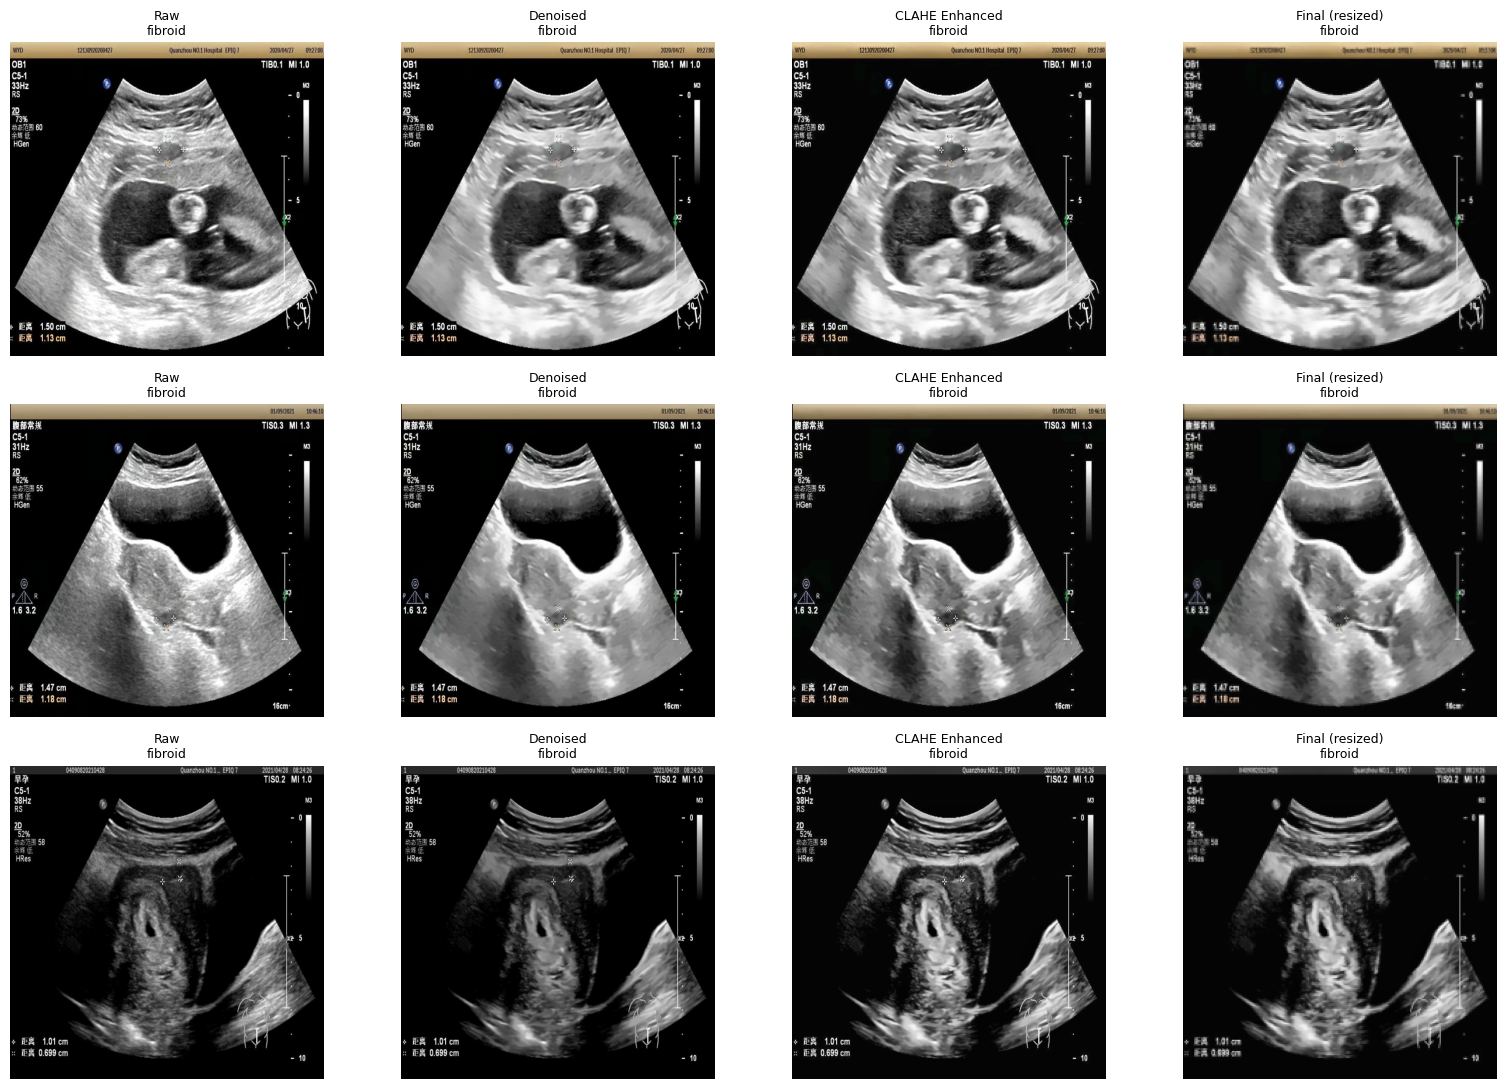

In [34]:
importlib.reload(pp)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
sample_check = df.sample(3, random_state=7)

for i, (_, row) in enumerate(sample_check.iterrows()):
    raw = pp.load_image(row['path'], color_mode='rgb')
    denoised = pp.denoise(raw)
    enhanced = pp.enhance_contrast(denoised)
    final = pp.resize_image(enhanced, pp.TARGET_SIZE)

    for j, (img, title) in enumerate([(raw, 'Raw'), (denoised, 'Denoised'),
                                        (enhanced, 'CLAHE Enhanced'), (final, 'Final (resized)')]):
        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{title}\n{row['class']}", fontsize=9)
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('docs/preprocessing_before_after.png', dpi=150)
plt.show()

In [36]:
import tensorflow as tf
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(split_dir, target_size=(224, 224), batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        labels='inferred',
        label_mode='binary',
        class_names=['non_fibroid', 'fibroid'],  # explicit order: 0=non_fibroid, 1=fibroid
        image_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42
    )
    return ds

train_ds = make_dataset('data/splits/train', shuffle=True)
valid_ds = make_dataset('data/splits/valid', shuffle=False)
test_ds  = make_dataset('data/splits/test', shuffle=False)

print("Class order:", train_ds.class_names if hasattr(train_ds, 'class_names') else "check above")

Found 1778 files belonging to 2 classes.
Found 381 files belonging to 2 classes.
Found 381 files belonging to 2 classes.
Class order: ['non_fibroid', 'fibroid']


In [37]:
# Normalization layer — matches src/preprocess.py's normalize() but as a graph-friendly Keras layer
normalization_layer = tf.keras.layers.Rescaling(1./255)

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds_ready = prepare(train_ds, training=True)
valid_ds_ready = prepare(valid_ds)
test_ds_ready  = prepare(test_ds)

Batch shape: (32, 224, 224, 3)
Label shape: (32, 1)
Pixel value range: 0.0 - 1.0
Sample labels: [1. 0. 1. 0. 0. 1. 0. 0.]


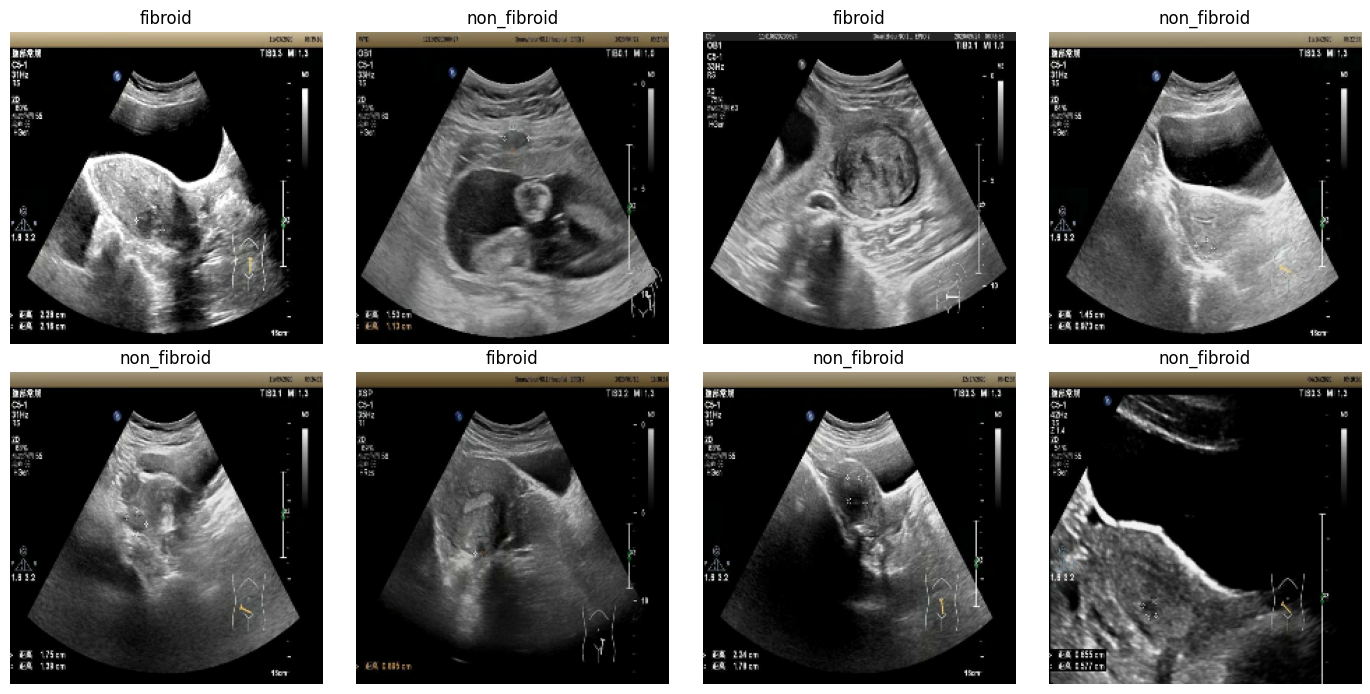

In [38]:
for images, labels in train_ds_ready.take(1):
    print("Batch shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Pixel value range:", images.numpy().min(), "-", images.numpy().max())
    print("Sample labels:", labels.numpy()[:8].flatten())

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy())
        ax.set_title('fibroid' if labels[i].numpy()[0] == 1 else 'non_fibroid')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [39]:
config = {
    'target_size': list(TARGET_SIZE),
    'batch_size': BATCH_SIZE,
    'class_order': ['non_fibroid', 'fibroid'],
    'blur_threshold': float(blur_threshold),
    'contrast_threshold': float(contrast_threshold),
}

import json
with open('src/preprocess_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(config)

{'target_size': [224, 224], 'batch_size': 32, 'class_order': ['non_fibroid', 'fibroid'], 'blur_threshold': 819.5125111226566, 'contrast_threshold': 47.62180024118173}


In [40]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   data/eda_inventory_final.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	docs/preprocessing_before_after.png
	src/preprocess.py
	src/preprocess_config.json



In [41]:
!git add src/preprocess.py
!git add src/preprocess_config.json
!git add docs/preprocessing_before_after.png
!git add notebooks/02_preprocessing.ipynb

In [42]:
!git add data/eda_inventory_final.csv

In [43]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   data/eda_inventory_final.csv
	new file:   docs/preprocessing_before_after.png
	new file:   src/preprocess.py
	new file:   src/preprocess_config.json



In [45]:
!git config --global user.name "Shravani046"
!git config --global user.email "Shravanimogarkar@gmail.com"

In [46]:
!git commit -m "Implemented data loading and cleaning along with preprocessing pipeline and image quality analysis"
!git push

[main 2ca1403] Implemented data loading and cleaning along with preprocessing pipeline and image quality analysis
 4 files changed, 2581 insertions(+), 2460 deletions(-)
 create mode 100644 docs/preprocessing_before_after.png
 create mode 100644 src/preprocess.py
 create mode 100644 src/preprocess_config.json
Enumerating objects: 14, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 1.97 MiB | 3.13 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Shravani046/Fibroid-Classification.git
   ebc55e3..2ca1403  main -> main
